# Pub/Sub y Cloud Functions

Vamos a armar una aplicación que produzca data, para luego ser almacenada en dos repositorios distintos, uno para backup y otro para análisis.
Para esto, necesitaremos:
- Pub/Sub.
- Bigquery.
- Aplicación en Python.
- Google Cloud Storage.
- Cloud Functions.

En Pub/Sub:
- Publisher: Aplicación con Python.
- Subscriber 1: Google Cloud Storage.
- Subscriber 2: Google BigQuery.


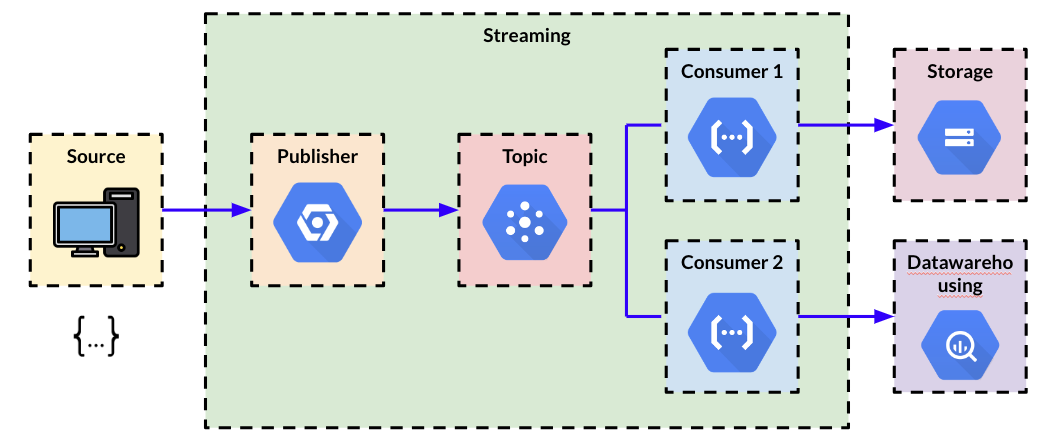

## Publisher

Aplicación en Python que genera data. Podemos correr esto en Compute Engine, o en local. Por el momento, utilizaremos Google Colab.

In [1]:
!pip install Faker

     ---------------------------------------- 2.0/2.0 MB 15.9 MB/s eta 0:00:00


You should consider upgrading via the 'C:\Users\e.rangel\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip' command.


In [4]:
!pip install google-cloud-pubsub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.9/194.9 kB 14.0 MB/s eta 0:00:00
  Attempting uninstall: importlib-metadata
    Found existing installation: importlib_metadata 8.7.0
    Uninstalling importlib_metadata-8.7.0:
      Successfully uninstalled importlib_metadata-8.7.0


In [1]:
from google.colab import auth
auth.authenticate_user()

In [3]:
from concurrent import futures
from google.cloud import pubsub_v1
from typing import Callable
import random
import json
from faker import Faker
import time
from datetime import datetime

# Configuración de proyecto y topic
project_id = "lustrous-setup-457000-h5"
topic_id = "topic-pubsub-cloudfunctions"

publisher = pubsub_v1.PublisherClient()
# Crear el path al topic
topic_path = publisher.topic_path(project_id, topic_id)

# Verificar si el topic existe y crearlo si no existe
try:
    publisher.get_topic(request={"topic": topic_path})
    print(f"Topic {topic_path} already exists.")
except Exception as e:
    print(f"Topic {topic_path} not found. Creating topic.")
    publisher.create_topic(request={"name": topic_path})


# Crear una instancia de Faker para generar datos ficticios
fake = Faker()

# Inicializar el cliente de Pub/Sub
# publisher = pubsub_v1.PublisherClient()
# # Crear el path al topic
# topic_path = publisher.topic_path(project_id, topic_id)

# Lista para almacenar futuros de publicación
publish_futures = []

# Función para manejar el resultado de la publicación
def get_callback(publish_future: pubsub_v1.publisher.futures.Future, data: str) -> Callable[[pubsub_v1.publisher.futures.Future], None]:
    def callback(publish_future: pubsub_v1.publisher.futures.Future) -> None:
        try:
            # Esperar hasta 60 segundos para que la publicación tenga éxito
            print(publish_future.result(timeout=60))
        except futures.TimeoutError:
            print(f"Publicación de {data} se agotó el tiempo.")

    return callback

# Bucle para generar y publicar mensajes
for i in range(50):
    # Generar datos ficticios para una transacción
    cantidad = random.randint(1,30)
    precioUni = round(random.uniform(10, 1000), 2)
    payload = {
        "IdTrx" : fake.random_number(digits=10),
        "Producto" : fake.vin(),
        "Cantidad" : cantidad,
        "PrecioUni" : precioUni,
        "PrecioTot" : round(cantidad * precioUni,2),
        "Cliente" : fake.ascii_free_email(),
        "Direccion" : fake.address(),
        "HoraTrx" : datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    # Convertir los datos a formato JSON y mostrarlos en la consola
    data = json.dumps(payload)
    print(data)

    # Esperar 2 segundos antes de continuar
    time.sleep(1)

    # Publicar el mensaje y agregar una función de callback para manejar el resultado
    publish_future = publisher.publish(topic_path, data.encode("utf-8"))
    publish_future.add_done_callback(get_callback(publish_future, data))
    publish_futures.append(publish_future)

# Esperar a que todos los futuros de publicación se resuelvan antes de salir
futures.wait(publish_futures, return_when=futures.ALL_COMPLETED)

# Mensaje de finalización
print(f"Se finalizó la transmisión al {topic_path}.")

Topic projects/lustrous-setup-457000-h5/topics/topic-pubsub-cloudfunctions already exists.
{"IdTrx": 9888975557, "Producto": "WWBNRNW617HM4UC4W", "Cantidad": 20, "PrecioUni": 820.68, "PrecioTot": 16413.6, "Cliente": "wwoodard@gmail.com", "Direccion": "30369 Taylor Expressway Apt. 869\nWest Dana, NV 05085", "HoraTrx": "2025-05-16 03:02:40"}
{"IdTrx": 2015764839, "Producto": "F62W4ZAN8SYHSHXTY", "Cantidad": 8, "PrecioUni": 215.99, "PrecioTot": 1727.92, "Cliente": "williamjohnston@gmail.com", "Direccion": "8836 Carla Crossing\nSouth Thomas, HI 06273", "HoraTrx": "2025-05-16 03:02:41"}
14852360266445923
{"IdTrx": 1633646673, "Producto": "H285ARS91NSU9GESH", "Cantidad": 11, "PrecioUni": 388.6, "PrecioTot": 4274.6, "Cliente": "stephanieblackburn@yahoo.com", "Direccion": "83366 Nicholas Oval\nPachecofurt, NE 95931", "HoraTrx": "2025-05-16 03:02:42"}
14854269744941009
{"IdTrx": 6259378351, "Producto": "0614VZLM8V4ML4L6B", "Cantidad": 17, "PrecioUni": 81.69, "PrecioTot": 1388.73, "Cliente": "yo

# Subscriber 1: Cloud Function que se conecta a Cloud Storage

Copiar el siguiente código dentro de una Cloud Function. Modificar el bucket name.
Prerequisitos:
- Crear un bucket.

In [ ]:
import functions_framework
import json
from google.cloud import storage
import uuid
from datetime import datetime
import base64

@functions_framework.cloud_event
def pubsub_to_json(cloud_event):
    # Obtener el mensaje del evento Pub/Sub
    message = base64.b64decode(cloud_event.data["message"]['data']).decode('utf-8')

    date_str = datetime.now().strftime('%Y%m%d')
    uuid_4dig = str(uuid.uuid4().hex)[:4]

    try:
        # Verificar que el mensaje no esté vacío
        if not message:
            print('Mensaje vacío. No se realizará ningún procesamiento.')
            return 'Mensaje vacío'

        # Convertir la cadena JSON a un objeto Python
        data = json.loads(message)

        # Obtener el nombre del bucket y el nombre del archivo de Cloud Storage
        bucket_name = 'sd-consola-bucket-g13-99'
        file_name = f'ingested/json/message_{date_str}_{uuid_4dig}.json'

        # Crear una instancia del cliente de Cloud Storage
        storage_client = storage.Client()

        # Obtener un bucket de Cloud Storage
        bucket = storage_client.bucket(bucket_name)

        # Crear un objeto Blob con el nombre del archivo JSON
        blob = bucket.blob(file_name)

        # Convertir el objeto Python a una cadena JSON
        json_data = json.dumps(data, indent=2)

        # Guardar la cadena JSON en el archivo en Cloud Storage
        blob.upload_from_string(json_data, content_type='application/json')

        print(f'Archivo JSON guardado en {bucket_name}/{file_name}')

        # Puedes agregar lógica adicional aquí si es necesario

        return 'Procesamiento completado'
    except json.JSONDecodeError as e:
        print(f'Error al analizar el mensaje JSON: {str(e)}')
        return 'Error al analizar el mensaje JSON'
    except Exception as e:
        print(f'Error al procesar el mensaje: {str(e)}')
        return 'Error al procesar el mensaje'

# Subscriber 2: BigQuery

Copiar el siguiente código dentro de una Cloud Function. Modificar el nombre del dataset y tabla.

In [ ]:
import json
from google.cloud import bigquery
import base64

def pubsub_to_bigquery(event, context):
    # Obtener el mensaje del evento Pub/Sub
    message = base64.b64decode(event['data']).decode('utf-8')

    try:
        # Verificar que el mensaje no esté vacío
        if not message:
            print('Mensaje vacío. No se realizará ningún procesamiento.')
            return 'Mensaje vacío'

        # Convertir la cadena JSON a un objeto Python
        data = json.loads(message)

        # Configurar la conexión a BigQuery
        bigquery_client = bigquery.Client()

        # Especificar el nombre de tu conjunto de datos y tabla en BigQuery
        #neural-truth-406011.raw_pubsub.tb_messages_pubsub
        dataset_id = 'smartdata_pubsub'
        table_id = 'target_pubsub'

        # Crear un objeto de referencia a la tabla de BigQuery
        table_ref = bigquery_client.dataset(dataset_id).table(table_id)
        table = bigquery_client.get_table(table_ref)

        # Insertar el mensaje en la tabla de BigQuery
        errors = bigquery_client.insert_rows_json(table, [data])

        if errors:
            print(f'Error al insertar datos en BigQuery: {errors}')
            return 'Error al insertar datos en BigQuery'

        print(f'Datos insertados en BigQuery: {data}')
        return 'Procesamiento completado'
    except json.JSONDecodeError as e:
        print(f'Error al analizar el mensaje JSON: {str(e)}')
        return 'Error al analizar el mensaje JSON'
    except Exception as e:
        print(f'Error al procesar el mensaje: {str(e)}')
        return 'Error al procesar el mensaje'
